In [ ]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
from pandas import DataFrame,Series

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns;

In [ ]:
df=pd.read_csv("/content/SOCR-HeightWeight.csv")
df

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682


In [ ]:
df.drop(columns="Index",inplace=True)

In [ ]:
df.shape

(25000, 2)

In [ ]:
df=df.head(50)
df.shape

(50, 2)

In [ ]:
df.columns

Index(['Height(Inches)', 'Weight(Pounds)'], dtype='object')

<Axes: xlabel='Height(Inches)', ylabel='Weight(Pounds)'>

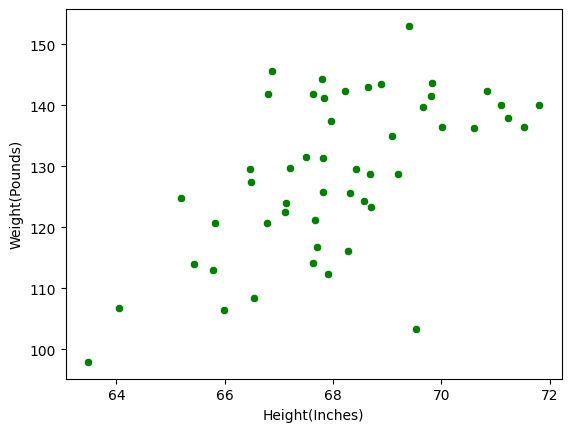

In [ ]:
sns.scatterplot(x=df["Height(Inches)"],y=df["Weight(Pounds)"],color="green")

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
individual_clustering_score=[]
for i in range(1,5): #i=1
  Kmeans=KMeans(n_clusters=i,init="random",random_state=42)
  Kmeans.fit(df)
  individual_clustering_score.append(Kmeans.inertia_)
print(individual_clustering_score)

[8302.549454637447, 2550.067897480504, 996.0635446735796, 727.7526866222425]


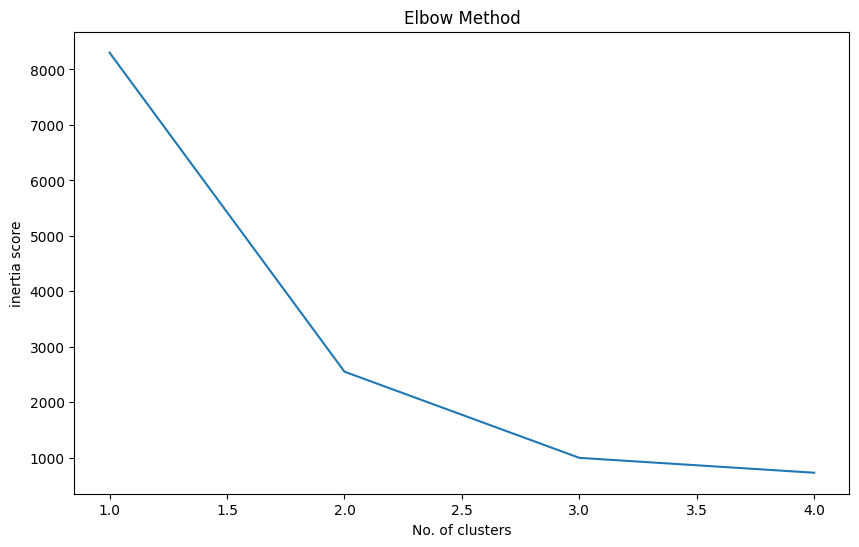

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,5),individual_clustering_score)
plt.title("Elbow Method")
plt.xlabel("No. of clusters")
plt.ylabel("inertia score")
plt.show()

elbow is at **2.0**

In [ ]:
Kmeans=KMeans(n_clusters=2,random_state=42)
Kmeans.fit(df)

KMeans(n_clusters=2, random_state=42)

In [ ]:
pred=Kmeans.predict(df)
pred

array([1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0], dtype=int32)

In [ ]:
df["Cluster"]=pd.DataFrame(pred,columns=["cluster"])

/tmp/ipykernel_487/3230194058.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Cluster"]=pd.DataFrame(pred,columns=["cluster"])


In [ ]:
df.head()

,Height(Inches),Weight(Pounds),Cluster
0,65.78331,112.9925,1
1,71.51521,136.4873,0
2,69.39874,153.0269,0
3,68.21660,142.3354,0
4,67.78781,144.2971,0


<Axes: xlabel='Height(Inches)', ylabel='Weight(Pounds)'>

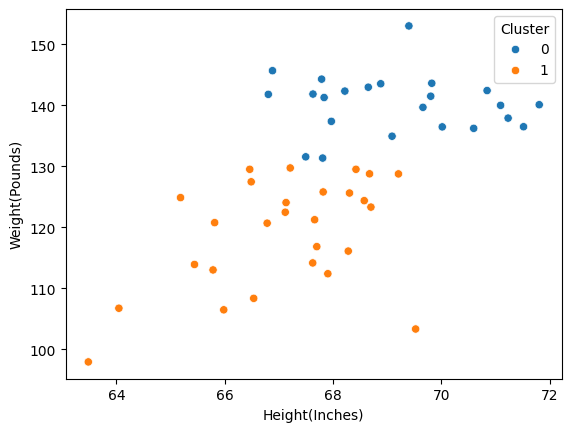

In [ ]:
sns.scatterplot(x=df["Height(Inches)"],y=df["Weight(Pounds)"],hue=df["Cluster"])

In [ ]:
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.mixture import GaussianMixture

In [ ]:
# Selecting features
X = df[['Height(Inches)', 'Weight(Pounds)']]
X

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [ ]:
print(df.columns)

Index(['Index', 'Height(Inches)', 'Weight(Pounds)'], dtype='object')


In [ ]:
# Train KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

In [ ]:
# Predict clusters
df['Cluster'] = kmeans.fit_predict(X)

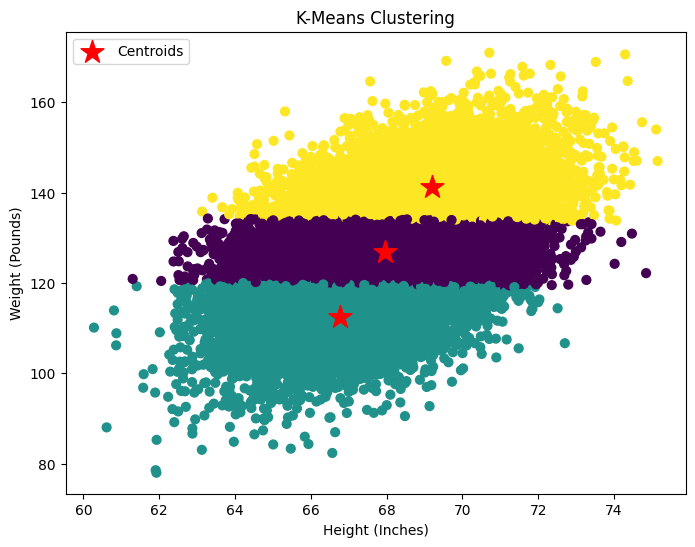

In [ ]:
# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X['Height(Inches)'],
    X['Weight(Pounds)'],
    c=df['Cluster'],
    cmap='viridis',
    s=40
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='*',
    s=300,
    c='red',
    label='Centroids'
)

plt.xlabel("Height (Inches)")
plt.ylabel("Weight (Pounds)")
plt.title("K-Means Clustering")
plt.legend()
plt.show()